# 6 &middot; Advanced PM: PGD Correction & Shell Strategies

This notebook assembles a production-style spherical lightcone and adds two ingredients that
matter for accurate maps:

- **PGD correction** (`PGDKernel`) — sharpens halo profiles that the finite PM force resolution
  would otherwise smooth out, restoring small-scale power;
- **shell partitioning** — how the comoving volume is sliced into shells (equal width vs equal
  volume vs the hybrid `jax_fli` default).


In [1]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

import jax_fli as jfli
from jax_fli import resolve_geometry

jax.config.update("jax_enable_x64", False)

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Configuration

In [2]:
key = jax.random.PRNGKey(0)
mesh_size = (64, 64, 64)
box_size = (2000.0, 2000.0, 2000.0)
nside = 64
nb_shells = 8
cosmo = jc.Planck18()

## Sharding, initial conditions, LPT

In [3]:
initial_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    nside=nside,
)
t0 = 0.1
dx, p = jfli.lpt(cosmo, initial_field, ts=t0, order=1)
print(f"LPT at a={t0}, mesh={mesh_size}, box={box_size[0]} Mpc/h")

LPT at a=0.1, mesh=(64, 64, 64), box=2000.0 Mpc/h


## The advanced solver: OnionTiler + PGD

- **`OnionTiler`** replicates and rotates the periodic box so a full-sky shell is painted
  without boundary artefacts (see [notebook 5](05-PM-Interpolation.ipynb)).
- **`PGDKernel`** (Potential Gradient Descent) nudges particle positions after each drift to
  restore the small-scale power the PM force resolution loses. It has three tunable numbers,
  `alpha` (strength), `kl` (large-scale cutoff) and `ks` (small-scale cutoff); they are
  *differentiable*, so they can be calibrated against a reference simulation.

It is dropped into the solver via the `pgd_kernel` argument — the rest of the pipeline is
unchanged.

In [4]:
solver = jfli.DoubleKickDrift(
    interp_kernel=jfli.OnionTiler(
        painting=jfli.PaintingOptions(target="spherical", scheme="ngp"),
        drift_on_lightcone=False,
    ),
    pgd_kernel=jfli.PGDKernel(alpha=0.3),  # <-- small-scale sharpening
    t0=t0,
    t1=1.0,
    n_steps=18,
)

## Run the lightcone

We slice the volume into `nb_shells` shells with the default **equal-comoving-width** spacing
and paint each onto a HEALPix map during the integration.

In [5]:
lightcone = jfli.nbody(cosmo, dx, p, nb_shells=nb_shells, solver=solver, shell_spacing="comoving")
print(f"{type(lightcone).__name__}  shape={lightcone.shape}")
print("comoving centers [Mpc/h]:", np.asarray(lightcone.comoving_centers).round(0))

SphericalDensity  shape=(8, 49152)
comoving centers [Mpc/h]: [ 62. 188. 312. 438. 562. 688. 812. 938.]


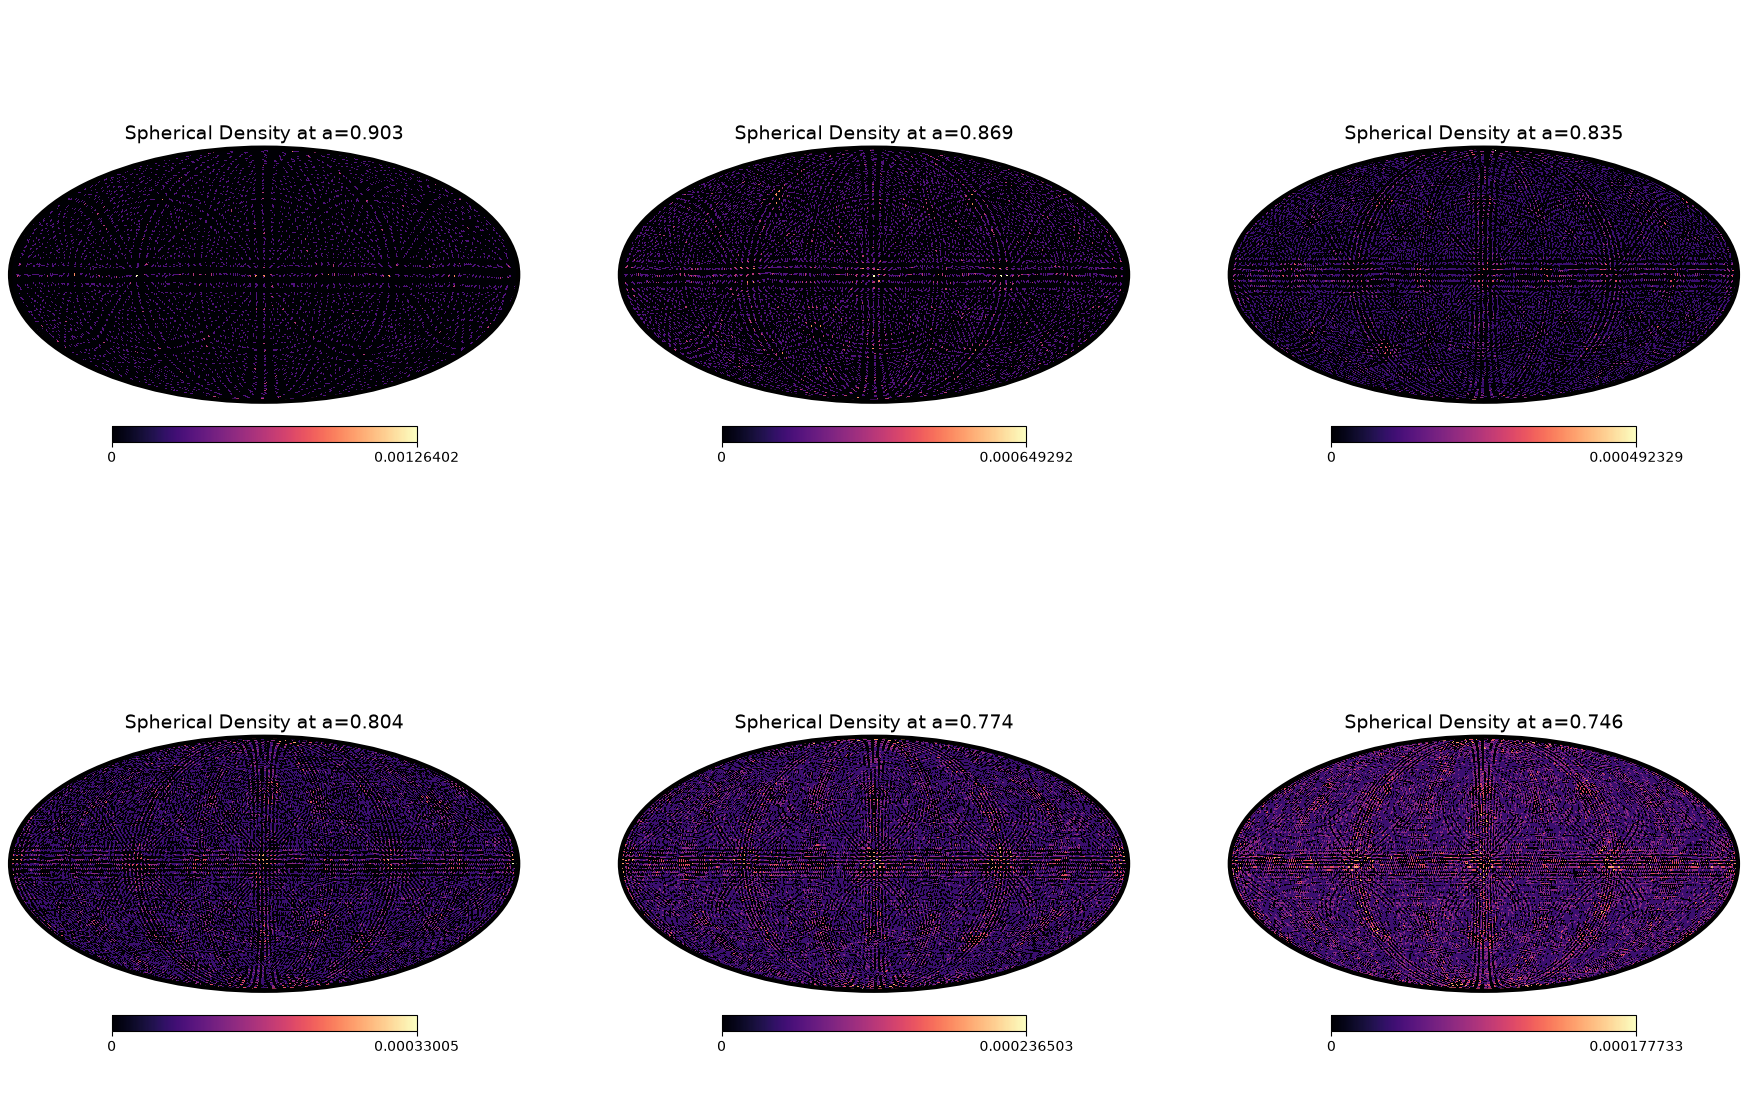

In [6]:
lightcone[-6:].apply_fn(jnp.log1p).show(ncols=3)

## Angular power spectra vs theory

Each shell is converted to **overdensity** (`per_plane`) and compared to the linear
`number_counts` prediction for a top-hat $n(z)$ spanning the shell.

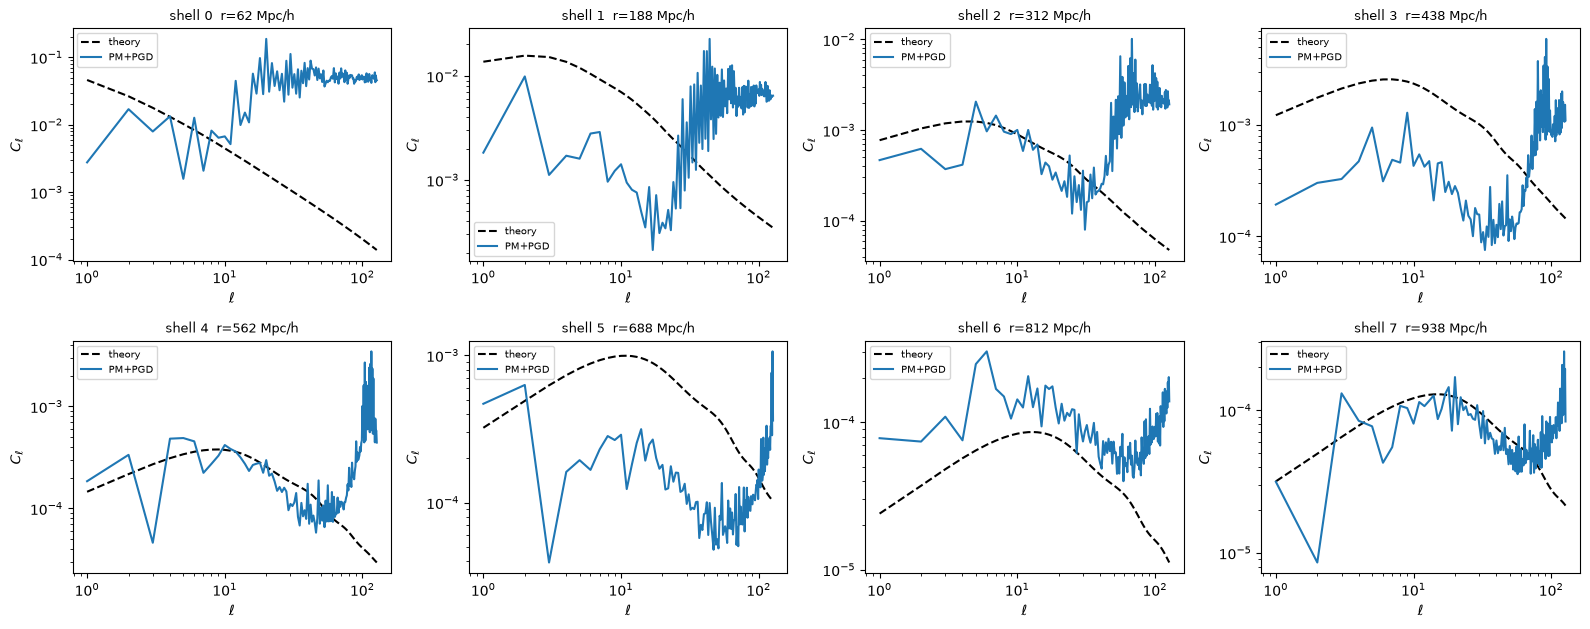

In [7]:
LMAX = 2 * nside
ells = jnp.arange(LMAX)

rc = np.asarray(lightcone.comoving_centers)
rw = np.asarray(lightcone.density_width)
z_near = np.asarray(jc.utils.a2z(jc.background.a_of_chi(cosmo, jnp.asarray(rc - rw / 2))))
z_far = np.asarray(jc.utils.a2z(jc.background.a_of_chi(cosmo, jnp.asarray(rc + rw / 2))))
nz_s = [jfli.tophat_z(float(zn), float(zf), gals_per_arcmin2=1.0) for zn, zf in zip(z_near, z_far)]

theory_cl = jfli.compute_theory_cl(
    cosmo, ell=ells, z_source=nz_s, probe_type="number_counts", nonlinear_fn="halofit", cross=False
)
cl_meas = lightcone.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(method="healpy", lmax=LMAX - 1)

th = np.asarray(theory_cl.array)
me = np.asarray(cl_meas.array)
L = np.arange(1, LMAX)
ncols = 4
nrows = (nb_shells + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = axes.flatten()
for i in range(nb_shells):
    axes[i].loglog(L, th[i, 1:], "k--", label="theory")
    axes[i].loglog(L, me[i, 1:], color="C0", label="PM+PGD")
    axes[i].set_title(f"shell {i}  r={float(rc[i]):.0f} Mpc/h", fontsize=9)
    axes[i].set_xlabel(r"$\ell$")
    axes[i].set_ylabel(r"$C_\ell$")
    axes[i].legend(fontsize=7)
for i in range(nb_shells, len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.show()

## Shell partitioning: how the volume is sliced into shells

The lightcone volume can be sliced into `nb_shells` shells in several ways, selected with
`shell_spacing=` and resolved by the public `resolve_geometry` API:

- **`"comoving"` (equal width)** — boundaries evenly spaced in comoving distance ($dr=$ const).
  A shell's volume grows as $4\pi r^2\,dr$, so outer shells hold disproportionately more particles.
- **`"a"`** — boundaries evenly spaced in scale factor (equal steps in cosmic time variable $a$).
- **`"growth"`** — boundaries evenly spaced in the linear growth factor $D_+(a)$.
- **`"equal_vol"`** — every shell encloses the **same comoving volume**; outer shells are thin in
  radius but hold a **uniform particle count**. This is the lever for the near-shell **shot-noise**
  problem: equal-width shells starve the inner shells of particles, equal-volume shells do not.

`resolve_geometry`'s `min_width` is **only a validation guardrail** — it raises if a shell would be
thinner than the floor, but it never reshapes the edges. It is *not* a knob you tune to fix the
geometry: equal-volume already flattens the particle count on its own. Set it small (here
`min_width=1.0`) when you just want to read back the raw geometry.

The **top row** draws the four layouts. The **bottom row** compares, per shell, the **width**, the
**volume**, and the **predicted particle count**. The particle count is the mean $\bar n\,V_{\rm shell}$
($\bar n = N_{\rm part}/V_{\rm box}$), with an error bar from late-time clumping: at lower redshift
particles have moved by an rms Zel'dovich displacement $\sigma_{\rm disp}(z)$ (from the linear
$P(k)$), blurring the shell edges. The band is the number of particles sitting within one
$\sigma_{\rm disp}$ of the two boundaries — it grows toward late times and for thin shells, while
equal volume keeps the **central** count flat across shells.

comoving edges  : [   0.  125.  250.  375.  500.  625.  750.  875. 1000.]
equal_vol edges : [   0.  500.  630.  721.  794.  855.  909.  956. 1000.]


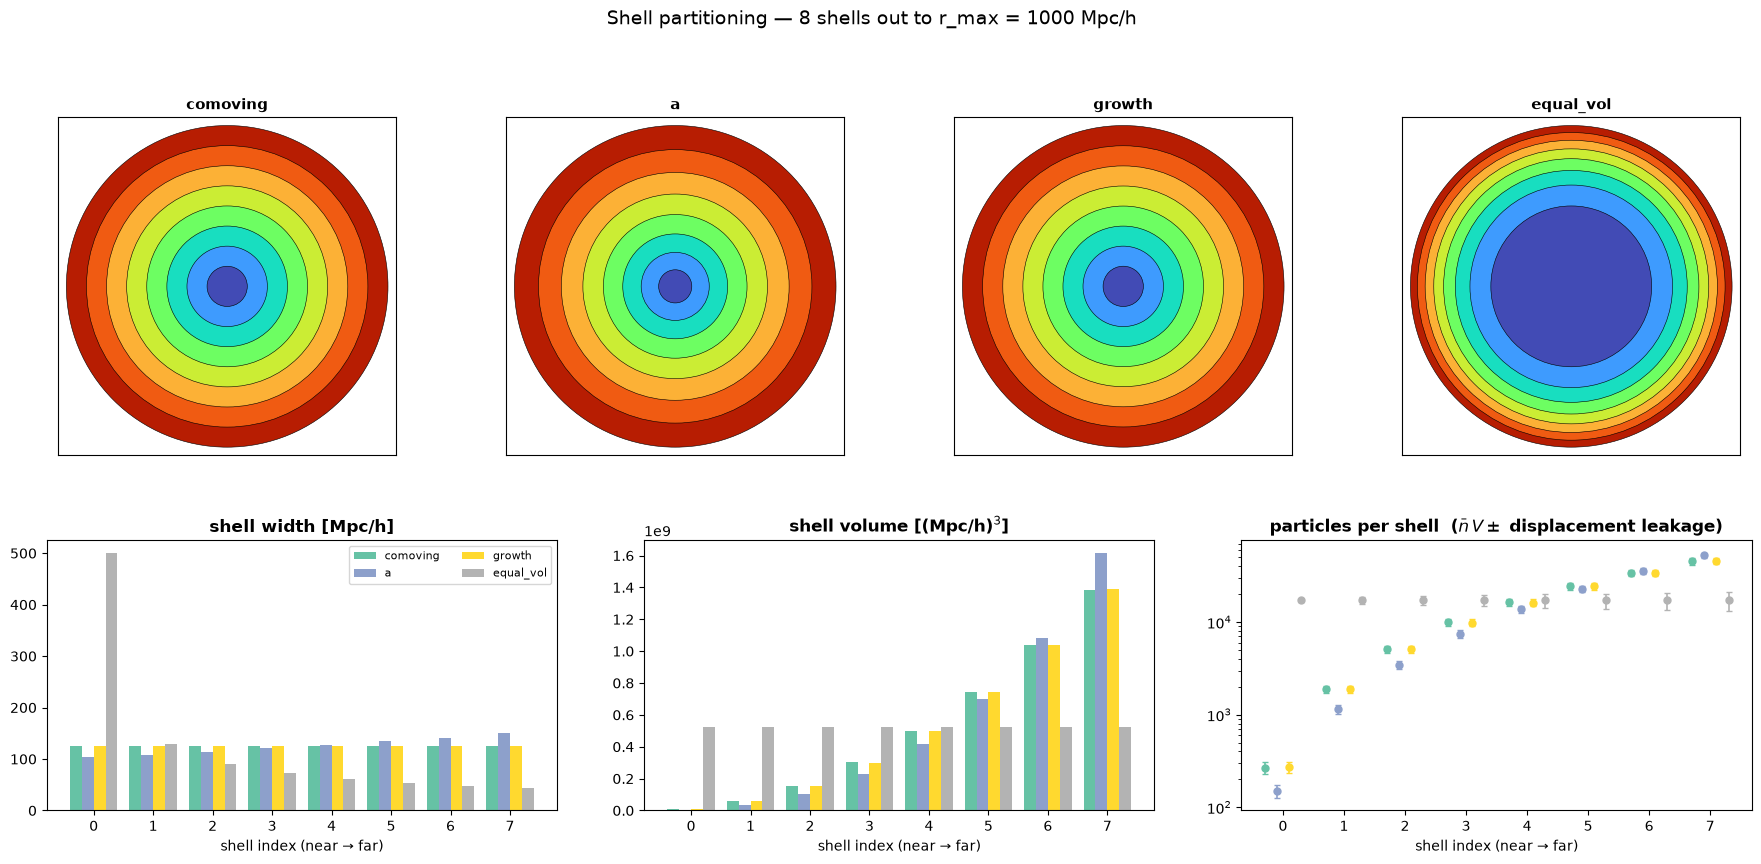

In [8]:
# Four shell layouts, all straight from the public resolve_geometry API.
r_max = float(initial_field.max_comoving_radius)  # comoving extent the lightcone actually fills (~box/2)


def edges_from_resolve(spacing):
    """resolve_geometry -> ascending (near->far) shell edges; it returns centres sorted far->near."""
    # min_width=1.0: only a guardrail, disarmed here so we read back the raw geometry unchanged.
    _, r_centers, widths = resolve_geometry(cosmo, r_max, nb_shells=nb_shells, shell_spacing=spacing, min_width=1.0)
    widths = np.asarray(widths)[np.argsort(np.asarray(r_centers))]  # widths near->far
    return np.concatenate([[0.0], np.cumsum(widths)])  # shells tile [0, r_max] contiguously


edges = {
    "comoving": edges_from_resolve("comoving"),
    "a": edges_from_resolve("a"),
    "growth": edges_from_resolve("growth"),
    "equal_vol": edges_from_resolve("equal_vol"),
}
names = list(edges)

print("comoving edges  :", edges["comoving"].round(0))
print("equal_vol edges :", edges["equal_vol"].round(0))

# ---- predicted particles per shell: mean nbar*V, with an rms-displacement boundary-leakage band ----
nbar = float(np.prod(mesh_size) / np.prod(box_size))  # particles per (Mpc/h)^3


def sigma_displacement(z):
    """rms 1D Zel'dovich displacement from the linear P(k) at redshift z (cf. 01-resolution build.py)."""
    a = 1.0 / (1.0 + z)
    k = jnp.logspace(-4, 1.3, 4000)
    pk = jc.power.linear_matter_power(cosmo, k, a=a)
    return float(jnp.sqrt(jnp.trapezoid(pk, k) / (6 * np.pi**2)))


def particles_per_shell(shell_edges):
    """Mean particle count per full-sky shell, and the +/- displacement boundary-leakage band."""
    r_near, r_far = shell_edges[:-1], shell_edges[1:]
    n_mean = nbar * (4 / 3) * np.pi * (r_far**3 - r_near**3)
    z_mid = np.asarray(jc.utils.a2z(jc.background.a_of_chi(cosmo, jnp.asarray(0.5 * (r_near + r_far)))))
    sig = np.array([sigma_displacement(float(z)) for z in z_mid])
    d_n = nbar * sig * 4 * np.pi * (r_near**2 + r_far**2)  # particles within 1 rms disp of the two edges
    return n_mean, d_n


# ---- figure: top row = 4 shell diagrams, bottom row = width / volume / particles ----
shell_colors = plt.cm.turbo(np.linspace(0.08, 0.92, nb_shells))  # ring colour by shell index
spacing_colors = plt.cm.Set2(np.linspace(0, 1, len(names)))  # one colour per spacing, shared below

fig = plt.figure(figsize=(22, 9))
gs = gridspec.GridSpec(2, 12, height_ratios=[1.25, 1.0], hspace=0.28, wspace=1.4)


def draw(ax, shell_edges, title):
    for i in range(nb_shells, 0, -1):  # outer-to-inner so inner rings sit on top
        ax.add_patch(plt.Circle((0, 0), float(shell_edges[i]), color=shell_colors[i - 1], ec="black", lw=0.4))
    ax.set(xlim=(-r_max * 1.05, r_max * 1.05), ylim=(-r_max * 1.05, r_max * 1.05), xticks=[], yticks=[])
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=11, fontweight="bold")


for col, name in enumerate(names):
    draw(fig.add_subplot(gs[0, 3 * col : 3 * col + 3]), edges[name], name)

x = np.arange(nb_shells)
bw = 0.8 / len(names)
ax_w = fig.add_subplot(gs[1, 0:4])
ax_v = fig.add_subplot(gs[1, 4:8])
ax_p = fig.add_subplot(gs[1, 8:12])

for j, name in enumerate(names):
    off = (j - (len(names) - 1) / 2) * bw
    ax_w.bar(x + off, np.diff(edges[name]), bw, color=spacing_colors[j], label=name)
    ax_v.bar(x + off, (4 / 3) * np.pi * np.diff(edges[name] ** 3), bw, color=spacing_colors[j])
    n_mean, d_n = particles_per_shell(edges[name])
    ax_p.errorbar(x + off, n_mean, yerr=d_n, fmt="o", ms=5, lw=1.2, capsize=2, color=spacing_colors[j])

ax_w.set_title("shell width [Mpc/h]", fontweight="bold")
ax_v.set_title(r"shell volume [(Mpc/h)$^3$]", fontweight="bold")
ax_p.set_title(r"particles per shell  ($\bar n\,V \pm$ displacement leakage)", fontweight="bold")
ax_p.set_yscale("log")
for ax in (ax_w, ax_v, ax_p):
    ax.set_xlabel("shell index (near → far)")
    ax.set_xticks(x)
ax_w.legend(fontsize=8, loc="upper right", ncol=2)
plt.suptitle(f"Shell partitioning — {nb_shells} shells out to r_max = {r_max:.0f} Mpc/h", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

### Equal-volume run

We rerun the same pipeline with `shell_spacing="equal_vol"`. Since `min_width` is only a guardrail
we disarm it (`min_width=1.0`) and let the equal-volume rule place the edges directly: the outer
shells come out thin in radius but hold the same particle count as the inner ones.

In [9]:
lightcone_eq = jfli.nbody(cosmo, dx, p, nb_shells=nb_shells, solver=solver, shell_spacing="equal_vol", min_width=1.0)
print("equal_vol centers:", np.asarray(lightcone_eq.comoving_centers).round(0))
print("equal_vol widths :", np.asarray(lightcone_eq.density_width).round(0))
print("comoving widths  :", np.asarray(lightcone.density_width).round(0))

equal_vol centers: [250. 565. 676. 757. 824. 882. 933. 978.]
equal_vol widths : [500. 130.  91.  73.  61.  54.  48.  44.]
comoving widths  : [125. 125. 125. 125. 125. 125. 125. 125.]


### Spectra: equal width vs equal volume

Same realization, two slicings. Equal-volume shells hold a more uniform particle count, which
shows up as more consistent shot-noise floors across shells.

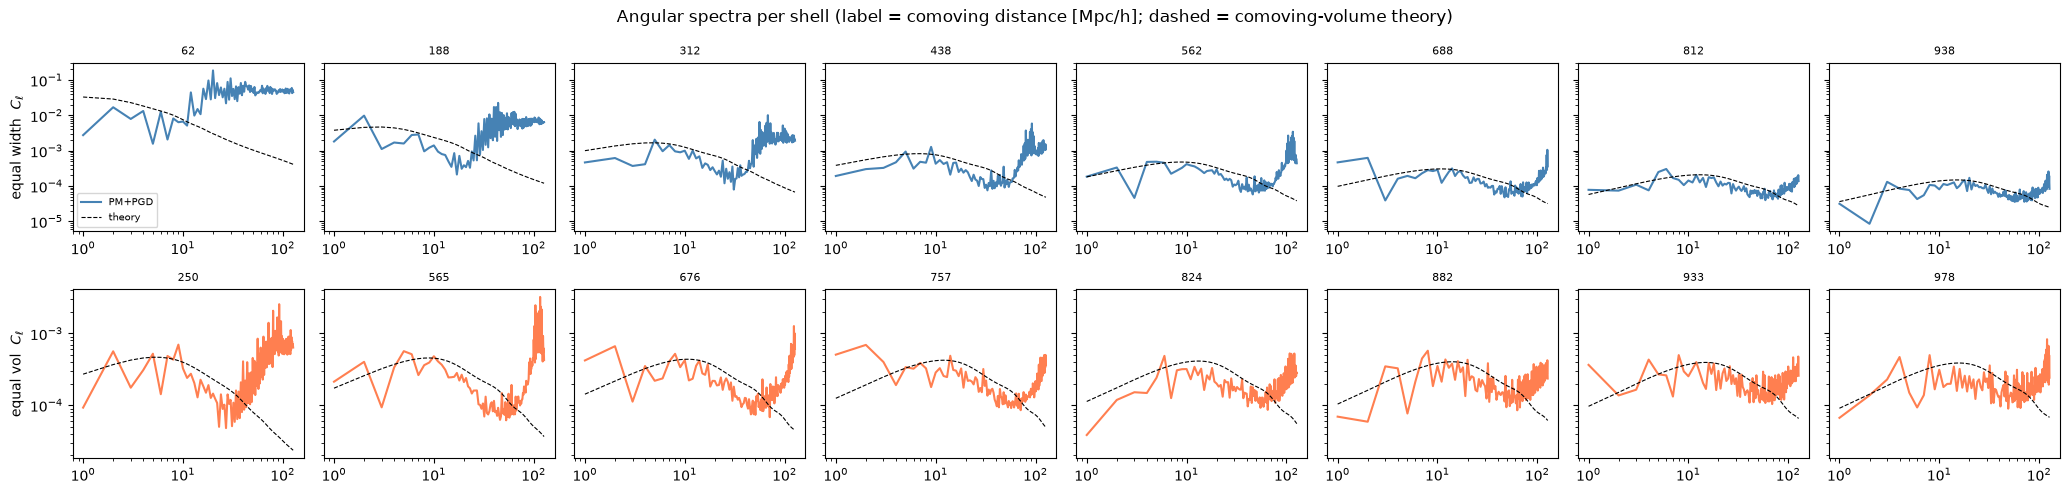

In [10]:
cl_def = lightcone.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(method="healpy", lmax=LMAX - 1)
cl_eq = lightcone_eq.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(method="healpy", lmax=LMAX - 1)
A = np.asarray(cl_def.array)
B = np.asarray(cl_eq.array)

# Edge-exact comoving-volume number-counts theory per shell, straight from each lightcone's geometry.
th_def = np.asarray(jfli.compute_theory_cl_for_density(cosmo, lightcone, ells, nonlinear_fn="halofit").array)
th_eq = np.asarray(jfli.compute_theory_cl_for_density(cosmo, lightcone_eq, ells, nonlinear_fn="halofit").array)

fig, axes = plt.subplots(2, nb_shells, figsize=(2.6 * nb_shells, 5), sharey="row")
for c in range(nb_shells):
    axes[0, c].loglog(L, A[c, 1:], color="steelblue", label="PM+PGD")
    axes[0, c].loglog(L, th_def[c, 1:], "k--", lw=0.8, label="theory")
    axes[0, c].set_title(f"{float(lightcone.comoving_centers[c]):.0f}", fontsize=8)
    axes[1, c].loglog(L, B[c, 1:], color="coral")
    axes[1, c].loglog(L, th_eq[c, 1:], "k--", lw=0.8)
    axes[1, c].set_title(f"{float(lightcone_eq.comoving_centers[c]):.0f}", fontsize=8)
axes[0, 0].set_ylabel(r"equal width  $C_\ell$")
axes[1, 0].set_ylabel(r"equal vol  $C_\ell$")
axes[0, 0].legend(fontsize=7)
plt.suptitle(
    "Angular spectra per shell (label = comoving distance [Mpc/h]; dashed = comoving-volume theory)", fontsize=12
)
plt.tight_layout()
plt.show()

## Impact of time stepping

Equal-volume spacing fixes *where the particles land*; **time stepping** fixes *where the integration steps land*. The closer a shell is to the observer (late times, low $z$), the more non-linear it is and the more time resolution it could use — yet the standard schedules place the *fewest* steps there.

Writing the displacement as a growth-factor series $\Psi(q,a)=\sum_n \Psi^{(n)}(q)\,D^n(a)$, an integrator that is exact to $N$-th LPT order per step has a leading per-step residual $\propto D^{N+1}$. Equalising each step's contribution over a fixed budget then means stepping **uniformly in $\tau = D^{N+1}$** — i.e. $D^2$ for a FastPM-class ($N{=}1$) stepper and $D^3$ for BullFrog ($N{=}2$). These are the new `time_stepping="D2"` / `"D3"` options; the exponent is fixed by the integrator, so there is nothing to tune.

The helper `simulation_stepping` reproduces exactly what the integrator does (`integrate._fwd_loop`): it advances by a constant step in the chosen time variable, **clips the last step of every shell onto the shell centre**, and **stops at the nearest shell** — `t1` only sets the step size, the *targets* are the shell centres (`ts`). The figure mirrors the budget plot: step times in $a$, the same in comoving distance $\chi$ (drawn far $\to$ near, the integration direction), and the per-step resolution $\Delta a$, for `a` / `D` / `D2` / `D3`. Each scheme spends a long warm-up from $a_0$ to the far shell, then sweeps the shells; linear-`D` leaves the near shells with the bare minimum while `D2`/`D3` push resolution to late times — but note `D3`'s very large *first* step (visible as the high $\Delta a$ point on the left), the catch the next cell quantifies.

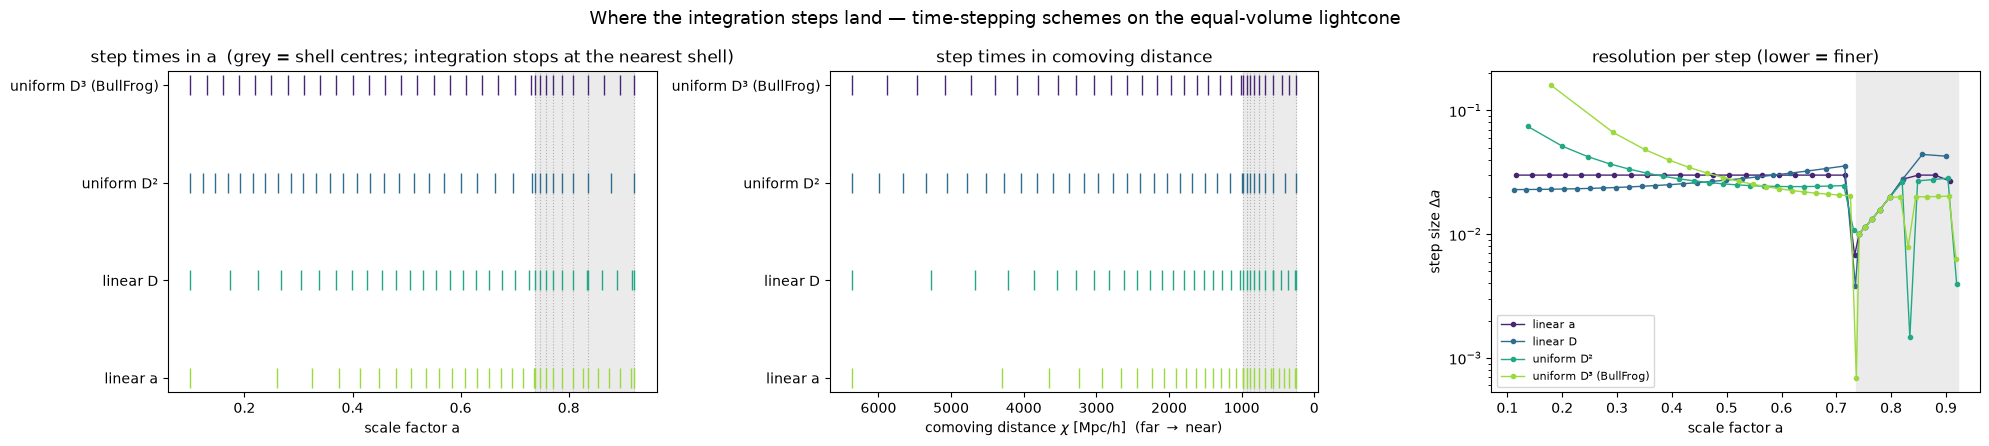

In [11]:
from jax_fli.pm._resolve_geometry import simulation_stepping

# The integrator's snapshot targets are the shell CENTRES (ts), and it STOPS at the last (nearest)
# centre — `t1` only sets the constant step size, not the endpoint (see integrate._fwd_loop: the outer
# scan runs over `ts`). So we mark the centres and shade the span the integrator actually covers.
ts_eq, rc_eq, dw_eq = resolve_geometry(cosmo, r_max, nb_shells=nb_shells, shell_spacing="equal_vol", min_width=1.0)
order = np.argsort(np.asarray(rc_eq))  # near -> far in r
centers_a = np.asarray(ts_eq)[order]  # shell centres in a (near -> far)
centers_chi = np.asarray(rc_eq)[order]  # shell centres in comoving distance (near -> far)

n_steps_demo = 30
schemes = {"a": "linear a", "D": "linear D", "D2": "uniform D²", "D3": "uniform D³ (BullFrog)"}
scol = dict(zip(schemes, plt.cm.viridis(np.linspace(0.1, 0.85, len(schemes)))))
visited = {
    s: np.asarray(
        simulation_stepping(
            cosmo,
            t0,
            1.0,
            n_steps_demo,
            nb_shells=nb_shells,
            max_comoving_distance=r_max,
            shell_spacing="equal_vol",
            min_width=1.0,
            time_stepping=s,
        )
    )
    for s in schemes
}
visited_chi = {s: np.asarray(jc.background.radial_comoving_distance(cosmo, jnp.asarray(v))) for s, v in visited.items()}

fig, (ax_a, ax_chi, ax_d) = plt.subplots(1, 3, figsize=(20, 4.5))
yvals = {s: len(schemes) - i for i, s in enumerate(schemes)}
ylab = list(schemes.values())[::-1]

# --- left: step times in a. Grey band = shell-centre span (integrator's snapshot range); dotted =
#     shell centres = the ts targets. Integration starts at t0 (warm-up, left of the band) and STOPS at
#     the nearest centre (right edge of the band) — there are no steps between it and the observer a=1. ---
ax_a.axvspan(float(centers_a.min()), float(centers_a.max()), color="0.92", zorder=0)
for c in centers_a:
    ax_a.axvline(float(c), color="0.7", ls=":", lw=0.8, zorder=1)
for s in schemes:
    ax_a.plot(visited[s], np.full_like(visited[s], yvals[s]), "|", ms=14, color=scol[s], zorder=2)
ax_a.set(
    yticks=list(yvals.values()),
    yticklabels=ylab,
    xlabel="scale factor a",
    title="step times in a  (grey = shell centres; integration stops at the nearest shell)",
)

# --- middle: step times in comoving distance, FAR -> NEAR so left->right matches the integration
#     direction (it sweeps from the far shell inward to the observer). ---
ax_chi.axvspan(float(centers_chi.min()), float(centers_chi.max()), color="0.92", zorder=0)
for c in centers_chi:
    ax_chi.axvline(float(c), color="0.7", ls=":", lw=0.8, zorder=1)
for s in schemes:
    ax_chi.plot(visited_chi[s], np.full_like(visited_chi[s], yvals[s]), "|", ms=14, color=scol[s], zorder=2)
ax_chi.invert_xaxis()  # large chi (far) on the left -> chi=0 (near/observer) on the right
ax_chi.set(
    yticks=list(yvals.values()),
    yticklabels=ylab,
    xlabel=r"comoving distance $\chi$ [Mpc/h]  (far $\to$ near)",
    title="step times in comoving distance",
)

# --- right: per-step resolution Δa vs a (log scale). This avoids comparing total step counts (which
#     differ per scheme); it shows directly that raw D3 spends a huge first step early and only refines
#     late, while linear a / D are more uniform. ---
for s in schemes:
    v = np.sort(visited[s])
    ax_d.semilogy(0.5 * (v[1:] + v[:-1]), np.diff(v), "o-", ms=3, lw=1.0, color=scol[s], label=schemes[s])
ax_d.axvspan(float(centers_a.min()), float(centers_a.max()), color="0.92", zorder=0)
ax_d.set(xlabel="scale factor a", ylabel=r"step size $\Delta a$", title="resolution per step (lower = finer)")
ax_d.legend(fontsize=8)

plt.suptitle("Where the integration steps land — time-stepping schemes on the equal-volume lightcone", fontsize=13)
plt.tight_layout()
plt.show()

### Does D³ converge better on the near shells?

We give all three schedules the **same 30-step budget** — `a`, `D`, and `D³` — slice the same equal-volume shells, and measure each shell's RMS fractional `C_ℓ` error ($10 \le \ell \le 100$) against a converged reference (BullFrog `D` at 60 steps, which every schedule converges to). The near shell is the most non-linear and the one D³ is meant to help. BullFrog, not the PGD `DoubleKickDrift` above, because the `D` / `D2` / `D3` schedules live on the pi-integrators.

The honest answer at this resolution is **no — raw D³ does not converge better on the near shell; it converges slower.** Even at 30 steps a uniform-`D³` schedule started from $a_0 = 0.1$ still spends a large first step (a = 0.1 → ≈ 0.37) that under-resolves the early, still-linear growth; that error is coherent and large-scale, so D³ sits a couple of percent off on *every* shell, the near one included, while `a` and `D` already track the reference to a few tenths of a percent across all scales. D³ does reach the same answer — its 60-step run agrees with the 60-step `D` run — but only at a higher step count, which is the report's warning that a raw `D³` power law "concentrates so hard it can starve" the early part of the integration.

So `D³` is a late-time *refinement* tool, not a drop-in win: it pays off with the report's recipe (keep the uniform-`D` baseline and subdivide *only* the late steps) or in a budget-starved regime where `D` itself under-resolves the near shells. At 64³ here `D` already nails them, so there is no headroom for D³ to gain — and its front-loaded first step costs accuracy instead.

near shell r = 250 Mpc/h — RMS frac. error (10≤ℓ≤100) at 30 steps:
  linear a : near  0.7%   all shells 0.7% 0.4% 0.2% 0.5% 0.4% 0.5% 0.6% 0.7%
  linear D : near  0.7%   all shells 0.7% 0.3% 0.2% 0.5% 0.3% 0.2% 0.5% 0.2%
  uniform D³: near  2.2%   all shells 2.2% 2.6% 2.6% 2.6% 2.6% 2.1% 2.2% 2.7%


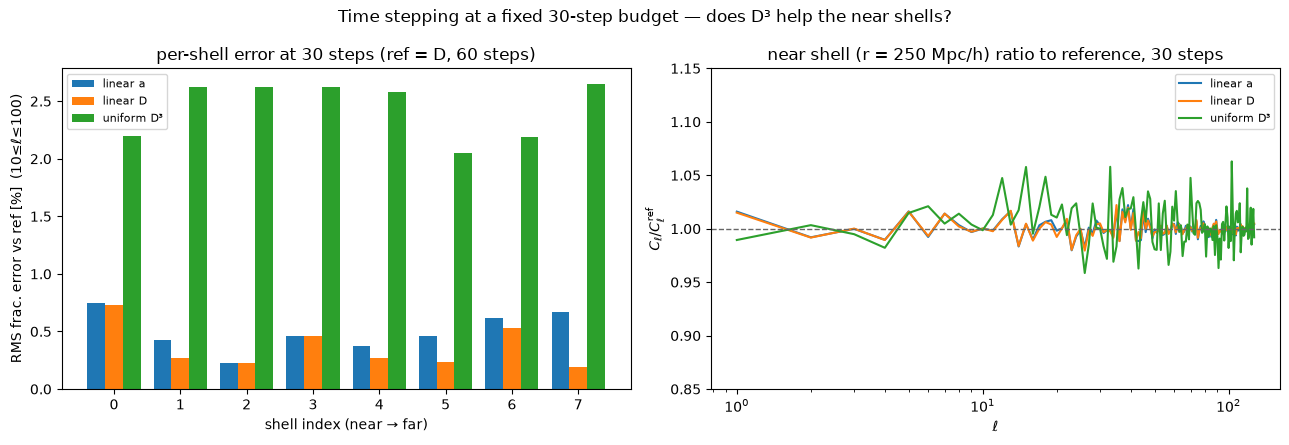

In [12]:
# --- Time stepping at a FIXED 30-step budget, vs a converged reference (BullFrog D, 60 steps) ---
# All three schedules get the SAME 30 steps; the question is which is most accurate per shell, and in
# particular whether D³ (which packs steps at late times) wins on the near shells. BullFrog, not the PGD
# DoubleKickDrift above, because the D / D2 / D3 schedules live on the pi-integrators.
def bf_cl(time_stepping, n_steps):
    s = jfli.BullFrog(
        interp_kernel=jfli.OnionTiler(
            painting=jfli.PaintingOptions(target="spherical", scheme="ngp"), drift_on_lightcone=False
        ),
        t0=t0,
        t1=1.0,
        n_steps=n_steps,
        time_stepping=time_stepping,
    )
    lc = jfli.nbody(cosmo, dx, p, nb_shells=nb_shells, solver=s, shell_spacing="equal_vol", min_width=1.0)
    cl = np.asarray(
        lc.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(method="healpy", lmax=LMAX - 1).array
    )
    return cl, lc


n_budget = 30
ref_cl, ref_lc = bf_cl("D", 60)  # converged reference; every schedule converges to this
runs = {ts: bf_cl(ts, n_budget)[0] for ts in ["a", "D", "D3"]}
labels = {"a": "linear a", "D": "linear D", "D3": "uniform D³"}
centers = np.asarray(ref_lc.comoving_centers)
near = int(np.argmin(centers))  # nearest (most non-linear) shell
band = (L >= 10) & (L <= 100)

per_shell = {
    ts: np.sqrt(np.mean((runs[ts][:, 1:][:, band] / ref_cl[:, 1:][:, band] - 1.0) ** 2, axis=1)) for ts in runs
}
print(f"near shell r = {centers[near]:.0f} Mpc/h — RMS frac. error (10≤ℓ≤100) at {n_budget} steps:")
for ts in runs:
    print(
        f"  {labels[ts]:9s}: near {per_shell[ts][near]:5.1%}   all shells "
        + " ".join(f"{e:4.1%}" for e in per_shell[ts])
    )

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
xs = np.arange(nb_shells)
bw = 0.8 / len(runs)
for j, ts in enumerate(runs):
    axL.bar(xs + (j - (len(runs) - 1) / 2) * bw, per_shell[ts] * 100, bw, label=labels[ts])
axL.set(
    xlabel="shell index (near → far)",
    ylabel="RMS frac. error vs ref [%]  (10≤ℓ≤100)",
    xticks=list(xs),
    title=f"per-shell error at {n_budget} steps (ref = D, 60 steps)",
)
axL.legend(fontsize=8)

for ts in runs:
    axR.semilogx(L, runs[ts][near, 1:] / ref_cl[near, 1:], label=labels[ts])
axR.axhline(1.0, color="0.4", ls="--", lw=1.0)
axR.set(
    xlabel=r"$\ell$",
    ylabel=r"$C_\ell / C_\ell^{\rm ref}$",
    ylim=(0.85, 1.15),
    title=f"near shell (r = {centers[near]:.0f} Mpc/h) ratio to reference, {n_budget} steps",
)
axR.legend(fontsize=8)
plt.suptitle(f"Time stepping at a fixed {n_budget}-step budget — does D³ help the near shells?", fontsize=12)
plt.tight_layout()
plt.show()

## Next

[08 &middot; Lensing](08-Lensing.ipynb) turns these spherical density shells into weak-lensing
convergence and shear maps, and saves them to catalogs.